In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [7]:
gender_df = pd.read_csv("gender_submission.csv")
test_df = pd.read_csv("test.csv")
train_df = pd.read_csv("train.csv")

In [8]:
gender_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [9]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [10]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
survival_count = train_df["Survived"].value_counts()
print(survival_count)

Survived
0    549
1    342
Name: count, dtype: int64


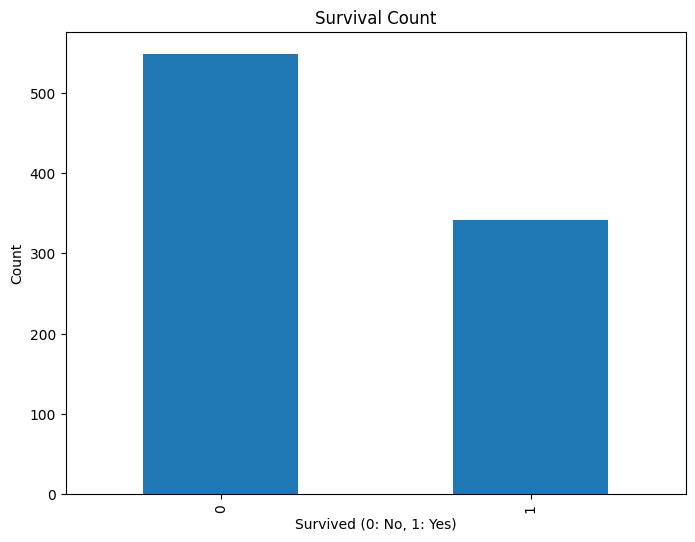

In [12]:
plt.figure(figsize=(8, 6))
survival_count.plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()

In [13]:
print(gender_df["PassengerId"].head())
print(test_df["PassengerId"].head())
print(train_df["PassengerId"].head())

0    892
1    893
2    894
3    895
4    896
Name: PassengerId, dtype: int64
0    892
1    893
2    894
3    895
4    896
Name: PassengerId, dtype: int64
0    1
1    2
2    3
3    4
4    5
Name: PassengerId, dtype: int64


In [14]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
train_df = pd.get_dummies(train_df, columns=["Embarked"])

In [16]:
test_df = pd.get_dummies(test_df, columns=["Embarked"])

In [17]:
train_df["Sex"] = train_df["Sex"].map({"male": 0, "female": 1})

In [18]:
test_df["Sex"] = test_df["Sex"].map({"male": 0, "female": 1})

In [19]:
test_df["Age"].isna().sum()

np.int64(86)

In [20]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,True,False,False


# Filling Age null Values using Random Forest


In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
def fillAge(df):
    age_feature = [
        "Pclass",
        "Sex",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked_C",
        "Embarked_Q",
        "Embarked_S",
    ]
    known_age = df[df["Age"].notnull()]
    unknown_age = df[df["Age"].isnull()]
    x_train = known_age[age_feature]
    y_train = known_age["Age"]

    x_test = unknown_age[age_feature]
    rf = RandomForestRegressor(n_estimators=100, random_state=42)

    rf.fit(x_train, y_train)

    predicted_ages = rf.predict(x_test)
    df.loc[df["Age"].isnull(), "Age"] = predicted_ages

    return df

In [23]:
fillAge(test_df)
fillAge(train_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,NaN,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,NaN,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False


In [24]:
train_df["Age"].isna().sum()

np.int64(0)

In [25]:
test_df["Age"].isna().sum()

np.int64(0)

In [26]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,NaN,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,NaN,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False


In [27]:
train_df["Cabin"].isna().sum()

np.int64(687)

In [28]:
print(train_df["Cabin"].isnull().sum(), "out of", train_df.shape[0])

687 out of 891


In [29]:
print(test_df["Cabin"].isnull().sum(), "out of", test_df.shape[0])

327 out of 418


In [30]:
train_df["Cabin"].value_counts

<bound method IndexOpsMixin.value_counts of 0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object>

In [31]:
test_df["Cabin"].value_counts

<bound method IndexOpsMixin.value_counts of 0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
413     NaN
414    C105
415     NaN
416     NaN
417     NaN
Name: Cabin, Length: 418, dtype: object>

In [32]:
df1 = train_df.drop(["Cabin"], axis=1)
df2 = train_df.copy()
df2["Cabin"] = df2["Cabin"].fillna("Unknown")

In [33]:
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,True,False,False


In [34]:
test1 = test_df.drop(["Cabin"], axis=1)
test2 = test_df.copy()
test2["Cabin"] = test2["Cabin"].fillna("Unknown")

In [35]:
df2["Cabin_letter"] = train_df["Cabin"].astype(str).str[0]
df2["Cabin_letter"].replace("n", "u", inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12624\3027342741.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Cabin_letter"].replace("n", "u", inplace=True)


In [36]:
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Cabin_letter
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,Unknown,False,False,True,u
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True,u
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True,C
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,Unknown,False,False,True,u
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,Unknown,False,False,True,u
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,Unknown,False,False,True,u
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False,C


In [37]:
test2["Cabin_letter"] = test_df["Cabin"].astype(str).str[0]
test2["Cabin_letter"].replace("n", "u", inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12624\1227855287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test2["Cabin_letter"].replace("n", "u", inplace=True)


In [38]:
df2 = train_df.copy()
df2["Cabin"] = df2["Cabin"].fillna("Unknown")
df2["Cabin_letter"] = df2["Cabin"].astype(str).str[0]
df2["Cabin_letter"] = df2["Cabin_letter"].replace("n", "u")

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2["Cabin_letter"] = le.fit_transform(df2["Cabin_letter"])
test2["Cabin_letter"] = le.fit_transform(test2["Cabin_letter"])

In [40]:
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Cabin_letter
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,Unknown,False,False,True,8
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True,8
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True,2
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,Unknown,False,False,True,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,Unknown,False,False,True,8
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,Unknown,False,False,True,8
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False,2


In [41]:
x1_train = df1.sample(frac=1).drop(["Name", "Ticket", "Survived"], axis=1)
x2_train = df2.sample(frac=1).drop(["Survived", "Cabin", "Name", "Ticket"], axis=1)
y_train = train_df.sample(frac=1)["Survived"]

In [42]:
gender_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [43]:
x1_test = test1.drop(["Name", "Ticket"], axis=1)
x2_test = test2.drop(["Cabin", "Name", "Ticket"], axis=1)
y_test = gender_df["Survived"]

In [44]:
x1_train.astype(int)
x2_train.astype(int)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Cabin_letter
48,49,3,0,22,2,0,21,1,0,0,8
67,68,3,0,19,0,0,8,0,0,1,8
806,807,1,0,39,0,0,0,0,0,1,0
213,214,2,0,30,0,0,13,0,0,1,8
457,458,1,1,40,1,0,51,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...
64,65,1,0,38,0,0,27,1,0,0,8
139,140,1,0,24,0,0,79,1,0,0,1
487,488,1,0,58,0,0,29,1,0,0,1
811,812,3,0,39,0,0,24,0,0,1,8


In [45]:
x1_test

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,892,3,0,34.500000,0,0,7.8292,False,True,False
1,893,3,1,47.000000,1,0,7.0000,False,False,True
2,894,2,0,62.000000,0,0,9.6875,False,True,False
3,895,3,0,27.000000,0,0,8.6625,False,False,True
4,896,3,1,22.000000,1,1,12.2875,False,False,True
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,26.370706,0,0,8.0500,False,False,True
414,1306,1,1,39.000000,0,0,108.9000,True,False,False
415,1307,3,0,38.500000,0,0,7.2500,False,False,True
416,1308,3,0,26.370706,0,0,8.0500,False,False,True


In [46]:
# Fill NaN values in Fare with mean
x1_test["Fare"] = x1_test["Fare"].fillna(x1_test["Fare"].mean())
# Convert to int after handling NaN values
x1_test = x1_test.astype(int)
# Same for x2_test
x2_test["Fare"] = x2_test["Fare"].fillna(x2_test["Fare"].mean())
x2_test = x2_test.astype(int)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_features = ["Age", "Fare"]

# Convert x1_train to DataFrame if it's not already
x1_train = pd.DataFrame(x1_train) if isinstance(x1_train, np.ndarray) else x1_train

# Standardize numerical features for training set
x1_train[numerical_features] = scaler.fit_transform(x1_train[numerical_features])

# Standardize numerical features for test set
x1_test[numerical_features] = scaler.transform(x1_test[numerical_features])

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x1_train_resampled, y_train_resampled = smote.fit_resample(x1_train, y_train)

In [49]:
x2_train

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Cabin_letter
48,49,3,0,22.948917,2,0,21.6792,True,False,False,8
67,68,3,0,19.000000,0,0,8.1583,False,False,True,8
806,807,1,0,39.000000,0,0,0.0000,False,False,True,0
213,214,2,0,30.000000,0,0,13.0000,False,False,True,8
457,458,1,1,40.062333,1,0,51.8625,False,False,True,3
...,...,...,...,...,...,...,...,...,...,...,...
64,65,1,0,38.344667,0,0,27.7208,True,False,False,8
139,140,1,0,24.000000,0,0,79.2000,True,False,False,1
487,488,1,0,58.000000,0,0,29.7000,True,False,False,1
811,812,3,0,39.000000,0,0,24.1500,False,False,True,8


In [45]:
print(y_train.value_counts())  # Check how many 0s vs. 1s

Survived
0    549
1    342
Name: count, dtype: int64


# RandomForestClassifier


In [113]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring="f1")
grid_search.fit(x1_train, y_train)
print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [63]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=100,
    random_state=42,
)
rfc.fit(x1_train_resampled, y_train_resampled)

RandomForestClassifier(max_depth=20, min_samples_split=5, random_state=42)

In [64]:
x1_test

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,892,3,0,0.323027,0,0,-0.507479,0,1,0
1,893,3,1,1.271747,1,0,-0.507479,0,0,1
2,894,2,0,2.366423,0,0,-0.467209,0,1,0
3,895,3,0,-0.187822,0,0,-0.487344,0,0,1
4,896,3,1,-0.552715,1,1,-0.406805,0,0,1
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,-0.260801,0,0,-0.487344,0,0,1
414,1306,1,1,0.687919,0,0,1.526125,1,0,0
415,1307,3,0,0.614941,0,0,-0.507479,0,0,1
416,1308,3,0,-0.260801,0,0,-0.487344,0,0,1


In [65]:
y_pred = rfc.predict(x1_test)

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.77      0.72       266
           1       0.48      0.36      0.41       152

    accuracy                           0.62       418
   macro avg       0.58      0.57      0.57       418
weighted avg       0.61      0.62      0.61       418



# XGBoost


In [70]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(x1_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [71]:
y_pred_xgb = xgb.predict(x1_test)

In [72]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.65      0.82      0.72       266
           1       0.42      0.23      0.30       152

    accuracy                           0.60       418
   macro avg       0.53      0.52      0.51       418
weighted avg       0.56      0.60      0.57       418



# Logistic Regression


In [67]:
from sklearn.linear_model import LogisticRegression

lgr = LogisticRegression()
lgr.fit(x1_train_resampled, y_train_resampled)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [68]:
y_pred_lgr = lgr.predict(x1_test)

In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.77      0.72       266
           1       0.48      0.36      0.41       152

    accuracy                           0.62       418
   macro avg       0.58      0.57      0.57       418
weighted avg       0.61      0.62      0.61       418

